In [13]:
import numpy as np
import matplotlib.pyplot as plt
import astropy.constants as cst
import astropy.units as u
import mpl_toolkits.mplot3d.axes3d as p3
import matplotlib.animation as animation
import sys
from matplotlib import rc

rc('font',**{'family':'serif','serif':['Palatino']})
rc('text', usetex=False)
rc('xtick', labelsize=20)
rc('ytick', labelsize=20)

In [14]:
def Runge_Kutta_w_acc(q0,qdot0,time_,acceleration,scale_factor=None):
     # Differential time_ and the length of the timing array
    dtime_ = time_[1] - time_[0]
    N_T = len(time_) - 1            
    
    qddot0 = acceleration(q0,qdot0)
    # Initializing the angular velocity and the angle arrays
    qDOT_ARRAY = [qdot0]
    qDDOT_ARRAY = [qddot0]
    q_ARRAY = [q0]
    
    qddot = qddot0
    qdot = qdot0
    q = q0
    #Loop for Euler's Method
    for i in range(N_T):
        t_step = time_[i]
        j1 = dtime_ * acceleration(q,qdot)
        
        k1 = dtime_ * qdot
        
        if scale_factor:
            k1 *= scale_factor
        
        j2 = dtime_ * acceleration(POS_=q+k1/2,VEL_=qdot+j1/2)
        k2 = dtime_ * (qdot + j2/2)
        
        if scale_factor:
            k2 *= scale_factor
            
        j3 = dtime_ * acceleration(q+k2/2,qdot+j2/2)
        k3 = dtime_ * (qdot + j3/2)
        
        if scale_factor:
            k3 *= scale_factor
        
        j4 = dtime_ * acceleration(q+k3,qdot+j3)
        k4 = dtime_ * (qdot+j4)
        
        if scale_factor:
            k4 *= scale_factor
        
        dq = 1./6 * (k1 + 2*k2 + 2*k3 + k4)
        dqdot = 1./6 * (j1 + 2*j2 + 2*j3 + j4)
        q_new = q+dq
        qdot_new = qdot+dqdot
        qddot_new = acceleration(q_new,qdot_new)
        
        q_ARRAY.append(q_new)
        qDOT_ARRAY.append(qdot_new)
        qDDOT_ARRAY.append(qdot_new)
        
        q = q_new
        qdot = qdot_new
        qddot = qddot_new
    
    q_ARRAY = np.array(q_ARRAY)
    qDOT_ARRAY = np.array(qDOT_ARRAY) 
    qDDOT_ARRAY = np.array(qDDOT_ARRAY)
    
    return q_ARRAY,qDOT_ARRAY,qDDOT_ARRAY
        

In [15]:
def spherical_to_cartesian(spherical):
    r = spherical[0]
    phi = spherical[1]
    theta = spherical[2]
    x = r*np.cos(phi)*np.sin(theta)
    y = r*np.sin(phi)*np.sin(theta)
    z = r*np.cos(theta)
    cartesian = np.array([x,y,z])
    return cartesian

In [16]:
def magnitude(vector):
    thing = 0
    for i in range(len(vector)):
        thing += vector[i]**2
    nrm = np.sqrt(thing)
    return nrm

In [17]:
def kr_delta(q,w):
    if q == w:
        return 0.
    else:
        return 1

Position will be in pc, Velocity in km s$^{-1}$, G in those units

$F = \frac{Gm^2}{d^2} \implies G = Fd^2/m^2 = mad^2/m^2 = \frac{\frac{v}{t}d^2}{m}$

$v \propto \textrm{km s}^{-1}$

$d \propto\textrm{AU}$

$\implies G \propto \frac{\textrm{km s}^{-1}\textrm{yr}^{-1}\textrm{AU}^2}{\textrm M_{\textrm J}}$

In [18]:
G = cst.G
M = 1.
N = 3
G_AU_w_units = G.to('km*AU^2/(M_jup*s*yr)')
G_pc_w_units = G.to('km*pc^2/(M_sun*s*Myr)')
G_pc = G_pc_w_units * u.M_sun * u.Myr * u.s/ ((u.pc)**2*u.km) #pc 2 km s -1 Msun -1 Myr -1
G_AU = G_AU_w_units * u.M_jup * u.yr * u.s/ ((u.AU)**2*u.km) #AU 2 km s -1 Mjup -1 yr -1

v1 = u.km/u.s * u.yr
v2 = u.km/u.s * u.Myr
to_au = v1.to('AU')  #Assuming a timescale of years
to_pc = v2.to('pc')  #Assuming a timescale of millions of years
to_au
G_AU = 0.178642
G_pc = 0.0043986004 

In [19]:
G_pc_w_units

<Quantity 0.0043986 km pc2 / (Myr s solMass)>

In [20]:
v1 = u.km/u.s * u.yr
to_au = v1.to('AU')
to_pc = v1.to('pc')
to_au

0.2109495265696987

Let's say we start with some set of initial position vectors ${\textbf{p}_i}(t)$, velocity vectors  $\textbf v_i(t)=\frac{d\textbf p_i}{dt}$, and acceleration vectors $\textbf{a}_i$:

Our position can be written as $\textbf p_i = r\hat{r} + r\phi\hat\phi + r\theta\sin\phi\hat\theta$

Then let's say we have some ensemble set of positions $\textbf{P} = \{\textbf{p}_1,\textbf p_2,\ldots,\textbf p_N\}$ and velocities $\textbf{V} = \{\textbf{v}_1,\textbf v_2,\ldots,\textbf v_N\}$. The acceleration for $\textbf{each}$ mass is a function of the ensemble positions and velocities:

$$
\begin{equation}
\textbf F_i = m_i\textbf a_i
\end{equation}
$$

$$
\begin{equation}
\implies m_i\textbf a_i = \sum_{\ell=0}^N \delta_{i\ell}\textbf F_{i\ell}
\end{equation}
$$

$$
\begin{equation}
\implies m_i\textbf a_i = -\sum_{\ell=1}^N\delta_{i\ell}\frac{Gm_im_\ell}{|\textbf p_i - \textbf p_\ell|^3}(\textbf p_i - \textbf p_\ell)
\end{equation}
$$

$$
\begin{equation}
\therefore \textbf a_i = -\sum_{\ell=1}^N \delta_{i\ell}\frac{Gm_{\ell}}{|\textbf p_i - \textbf p_\ell|^3}(\textbf p_i - \textbf p_\ell)
\end{equation}
$$

Similarly with positions and velocities, we can make a set of the acceleration vector for each mass: $\textbf A \equiv \{\textbf a_1,\textbf a_2, \ldots,\textbf a_N\}$, and we can write $\textbf A$ as a function of the position and velocity sets, as $\textbf A = \textbf A(\textbf P(t), \textbf V(t),t)$

In [21]:
mass_distribution = [1.]

In [22]:
def N_BODY_ACCELERATION(POS_,VEL_,N=2,m=mass_distribution,G=G_AU):
    acc_set = []
    for i in range(N):
        acc_i = np.zeros(3)
        for l in range(N):
            denom = (magnitude(POS_[i] - POS_[l]))**3
            if i != l:
                acc_i -= (G*m[l])/denom * (POS_[i] - POS_[l])
            else:
                acc_i -= 0
        acc_set.append(acc_i)
    acc_set = np.array(acc_set)
    return acc_set

In [23]:
def Runge_Kutta(q0,qdot0,time_,acceleration,scale_factor=None):
     # Differential time_ and the length of the timing array
    dtime_ = time_[1] - time_[0]
    N_T = len(time_) - 1            
    
    # Initializing the angular velocity and the angle arrays
    qDOT_ARRAY = [qdot0]
    q_ARRAY = [q0]
    
    qdot = qdot0
    q = q0
    #Loop for Euler's Method
    for i in range(N_T):
        t_step = time_[i]
        j1 = dtime_ * acceleration(q,qdot)
        k1 = dtime_ * qdot
        
        if scale_factor:
            k1 *= scale_factor
        
        j2 = dtime_ * acceleration(q+k1/2,qdot+j1/2)
        k2 = dtime_ * (qdot + j2/2)
        
        if scale_factor:
            k2 *= scale_factor
            
        j3 = dtime_ * acceleration(q+k2/2,qdot+j2/2)
        k3 = dtime_ * (qdot + j3/2)
        
        if scale_factor:
            k3 *= scale_factor
        
        j4 = dtime_ * acceleration(q+k3,qdot+j3)
        k4 = dtime_ * (qdot+j4)
        
        if scale_factor:
            k4 *= scale_factor
        
        dq = 1./6 * (k1 + 2*k2 + 2*k3 + k4)
        dqdot = 1./6 * (j1 + 2*j2 + 2*j3 + j4)
        q_new = q+dq
        qdot_new = qdot+dqdot
        q_ARRAY.append(q_new)
        qDOT_ARRAY.append(qdot_new)
        q = q_new
        qdot = qdot_new
    
    q_ARRAY = np.array(q_ARRAY)
    qDOT_ARRAY = np.array(qDOT_ARRAY) 
    
    print(q_ARRAY[-1]-q_ARRAY[0])
    return q_ARRAY,qDOT_ARRAY
        

# Generate masses/initial conditions

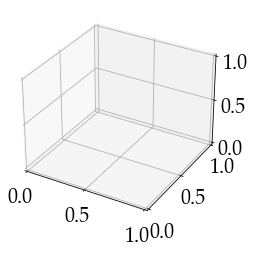

In [24]:
%matplotlib inline
INITIAL_POSITIONS = []
INITIAL_VELOCITIES = []
for i in range(N):
    r = 1e-8*np.random.random() #pc
    phi = 2*np.pi*np.random.random()  #radians
    theta = np.pi * np.random.random() #radians
    pos = np.array([r,r*phi,r*theta*np.sin(phi)])
    pos = spherical_to_cartesian(pos)
    
    v_mag = abs(np.random.normal(0,1.)) #magnitude of velocity
    vector = np.random.random(3)
    vector /= magnitude(vector)
    vel = v_mag * vector
    
    INITIAL_POSITIONS.append(pos)
    INITIAL_VELOCITIES.append(vel)
INITIAL_POSITIONS = np.array(INITIAL_POSITIONS)
INITIAL_VELOCITIES = np.array(INITIAL_VELOCITIES)

fig = plt.figure()
ax = fig.add_subplot(projection='3d')

In [25]:
VELS = []
for i in range(N):
    v_mag = magnitude(INITIAL_VELOCITIES[i])
    VELS.append(v_mag)
VELS = np.array(VELS)

(array([1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 1.]),
 array([0.442153  , 0.47556385, 0.50897469, 0.54238553, 0.57579637,
        0.60920721, 0.64261805, 0.67602889, 0.70943974, 0.74285058,
        0.77626142, 0.80967226, 0.8430831 , 0.87649394, 0.90990478,
        0.94331563]),
 <BarContainer object of 15 artists>)

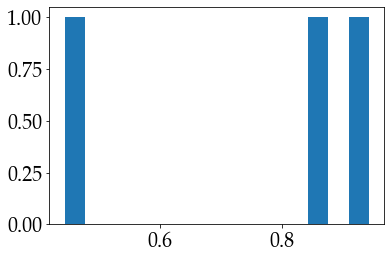

In [26]:
plt.hist(VELS,bins=15)

# Testing with Jupiter and the Sun

In [27]:
M_sun = 1047.35 #Jupiter masses
M_jup = 1. #Jupiter mass

mass_distribution = [M_sun,M_jup] # Jupiter masses
d_jup = 5.205 #AU
speed_jup = 13.609 #km s-1

d_sun = d_jup*M_jup/(M_sun+M_jup)
speed_sun = speed_jup*M_jup/(M_sun+M_jup)

p0_jup = np.array([d_jup,0.,0.]) #AU
v0_jup = np.array([0.,speed_jup,0.]) #km s-1

p0_sun = np.array([-d_sun,0.,0.]) #AU
v0_sun = np.array([0.,-speed_sun,0.]) #km s-1

time = np.linspace(0,100.,100000) #100 years of simulations
time[1] - time[0]

P0 = np.array([p0_sun,p0_jup])
V0 = np.array([v0_sun,v0_jup])

mass_distribution = np.array([M_sun,M_jup])

In [28]:
def N_BODY_ACCELERATION(POS_,VEL_,N=2,m=mass_distribution,G=G_AU):
    acc_set = []
    for i in range(N):
        acc_i = np.zeros(3)
        for l in range(N):
            denom = (magnitude(POS_[i] - POS_[l]))**3
            if i != l:
                acc_i -= (G*m[l])/denom * (POS_[i] - POS_[l])
            else:
                acc_i -= 0
        acc_set.append(acc_i)
    acc_set = np.array(acc_set)
    return acc_set

In [29]:
POSNS,VELS = Runge_Kutta(P0,V0,time,N_BODY_ACCELERATION,scale_factor=to_au)

[[ 8.01157917e-03 -4.53822571e-03  0.00000000e+00]
 [-8.39092745e+00  5.02695169e+00  0.00000000e+00]]


In [30]:
POSN_TPOSE = np.transpose(POSNS)
x_sun = POSN_TPOSE[0][0]
y_sun = POSN_TPOSE[1][0]

x_jup = POSN_TPOSE[0][1]
y_jup = POSN_TPOSE[1][1]

VEL_TPOSE = np.transpose(VELS)
vx_sun = VEL_TPOSE[0][0]
vy_sun = VEL_TPOSE[1][0]

vx_jup = VEL_TPOSE[0][1]
vy_jup = VEL_TPOSE[1][1]



# Animation Test for Partial Solar System 

In [31]:
def update_lines(num, dataLines, lines):
    for line, data in zip(lines, dataLines):
        # NOTE: there is no .set_data() for 3 dim data...
        line.set_data(data[0:2, :num])
        line.set_3d_properties(data[2, :num])
    return lines

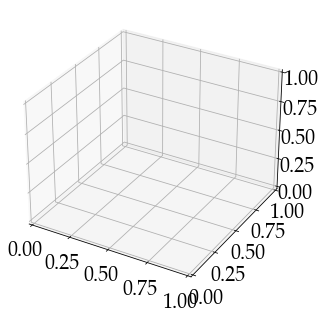

In [32]:
fig = plt.figure()
ax = p3.Axes3D(fig)

# Cluster

In [34]:
N=3
M = 10.  #solar mass
mass_distribution = M * np.ones(N)
def N_BODY_ACCELERATION(POS_,VEL_,N=N,m=mass_distribution,G=G_pc):
    acc_set = []
    for i in range(N):
        acc_i = np.zeros(3)
        for el in range(N):
            denom = (magnitude(POS_[i] - POS_[el]))**3
            if i != el:
                acc_i -= (G*m[el])/denom * (POS_[i] - POS_[el])
            else:
                acc_i -= 0
        acc_set.append(acc_i)
    acc_set = np.array(acc_set)
    return acc_set

In [35]:
def gen_positions(n):
    INITIAL_POSITIONS = []
    INITIAL_VELOCITIES = []
    for i in range(int(n)):
        r = np.random.normal(0.,1.) #pc
        phi = 2*np.pi*np.random.random()  #radians
        theta = np.pi * np.random.random() #radians
        pos = np.array([r,r*phi,r*theta*np.sin(phi)])
        pos = spherical_to_cartesian(pos)

        INITIAL_POSITIONS.append(pos)
    INITIAL_POSITIONS = np.array(INITIAL_POSITIONS)
    return INITIAL_POSITIONS

In [36]:
def gen_velocities(n,pos0):
        INITIAL_VELOCITIES = []
        
        mag_posn = []
        for j in range(n):
            mag_posn.append(magnitude(pos0[j]))
        R = max(mag_posn) - min(mag_posn)
        v_rms = np.sqrt(2*G_pc*M/R)         #getting velocity in km s-1
        for i in range(n):
            v_mag = abs(np.random.normal(0,v_rms/np.sqrt(3))) #magnitude of velocity
            vector = np.random.random(3)
            vector /= magnitude(vector)
            vector *= (-1)**np.random.choice(2)
            vel = v_mag * vector

            INITIAL_VELOCITIES.append(vel)
        INITIAL_VELOCITIES = np.array(INITIAL_VELOCITIES)
        return INITIAL_VELOCITIES

In [37]:
def gen_cluster(n):
    posn = gen_positions(n)
    veln = gen_velocities(n,posn)
    return posn,veln

## Find average separation

In [38]:
def average_sep(posn):
    mags = []
    for i in range(len(posn)):
        for j in range(len(posn)):
            if i != j:
                mags.append(magnitude(posn[i] - posn[j]))
    mags = np.array(mags)
    avg_sep = np.mean(mags)
    return avg_sep

In [59]:
%matplotlib qt
N_M = 3
inp = input('Velocities or Positions? ')
fig = plt.figure()
ax = fig.add_subplot(projection='3d')
pos0,vel0 = gen_cluster(N)
R_vir = average_sep(pos0)
epsilon = (4*np.pi/3 * R_vir**3)**(1./3) * N**(-1./3)
if inp == 'pos' or inp == 'position' or inp =='p':
    for position in pos0:
        x = position[0]
        y = position[1]
        z = position[2]
        ax.plot(x,y,z,'bo')
    ax.set_xlabel('$x$ (pc)')
    ax.set_ylabel('$y$ (pc)')
    ax.set_zlabel('$z$ (pc)')
elif inp =='vel' or inp == 'velocity' or inp =='v':
    for velocity in vel0:
        vx = velocity[0]
        vy = velocity[1]
        vz = velocity[2]
        ax.plot(vx,vy,vz,'ro')
    ax.set_xlabel('$v_x$ (km/s)')
    ax.set_ylabel('$v_y$ (km/s)')
    ax.set_zlabel('$v_z$ (km/s)')
else:
    print('Input stuff again')
plt.show()

Velocities or Positions? p


In [60]:
mag_vels = []
for i in range(len(vel0)):
    mag_vels.append(magnitude(vel0[i]))

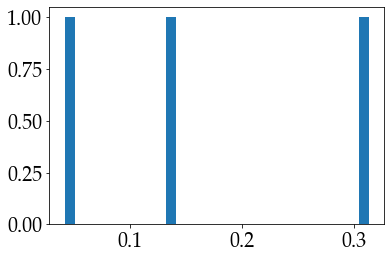

In [61]:
%matplotlib inline
plt.hist(mag_vels,bins=30)
plt.show()

In [62]:
def N_BODY_ACCELERATION_soft(POS_,VEL_,N=N,m=mass_distribution,G=G_pc,eps=epsilon):
    acc_set = []
    for i in range(N):
        acc_i = np.zeros(3)
        for el in range(N):
            if i != el:
                X = POS_[i] - POS_[el]
                denom = (magnitude(X))**3
                Xhat = X/(magnitude(X))
                if magnitude(X) >= epsilon:
                    acc_i -= (G*m[el])/denom * (X)
                else:
                    acc_i -= (G*m[el]) / (eps**2) * Xhat
            else:
                acc_i -= 0
        acc_set.append(acc_i)
    acc_set = np.array(acc_set)
    return acc_set

In [63]:
a = N_BODY_ACCELERATION_soft
a2 = N_BODY_ACCELERATION
acc = a(pos0,vel0)
acc2 = a2(pos0,vel0)

In [64]:
mag_accs = []
for i in range(N):
    mag_accs.append(magnitude(acc[i]))
mag_accs2 = []
for i in range(N):
    mag_accs2.append(magnitude(acc2[i]))

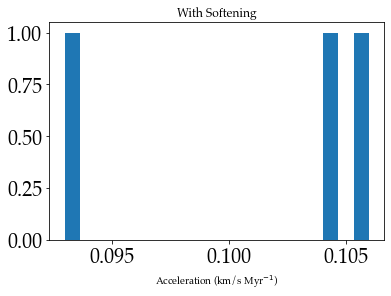

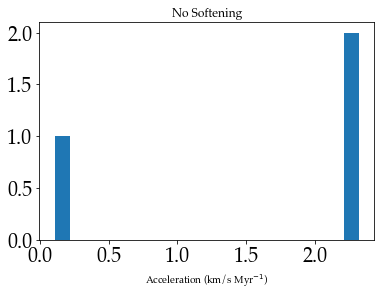

In [65]:
plt.hist(mag_accs,bins=20)
plt.xlabel('Acceleration (km/s Myr$^{-1}$)')
plt.title('With Softening')
plt.show()
plt.hist(mag_accs2,bins=20)
plt.xlabel('Acceleration (km/s Myr$^{-1}$)')
plt.title('No Softening')
plt.show()

In [66]:
def Runge_Kutta_w_acc_to_file(q0,qdot0,time_,acceleration,include_softening,scale_factor=None,N_M=N_M):
     # Differential time_ and the length of the timing array
    dtime_ = time_[1] - time_[0]
    N_T = len(time_) - 1  
    
    if include_softening:
        pointer = '/Users/jvazquez/Dropbox/Classes/Spring_2021/CompPhys/N_Body/Data/Simulation_Run/Softening/'
    else:
        pointer = '/Users/jvazquez/Dropbox/Classes/Spring_2021/CompPhys/N_Body/Data/Simulation_Run/No_Softening/'
    
    qddot0 = acceleration(q0,qdot0)
    # Initializing the angular velocity and the angle arrays
    qDOT_ARRAY = [qdot0]
    qDDOT_ARRAY = [qddot0]
    q_ARRAY = [q0]
    
    qddot = qddot0
    qdot = qdot0
    q = q0
    #Loop for Euler's Method
    files = []
    for k in range(N_M):
        file = open(pointer+'particle_%d.txt' % (k+1),'w')
        file.write('%d-Body Run with i = %d th particle. (Units in pc,M_solar,Myr, km s-1) \n\n' % (N_M, k+1))
        file.write('time\t\t x \t\t y \t\t z \t\t xdot \t\t ydot \t\t zdot \t\t xddot \t\t yddot \t\t zddot\n')
        files.append(file)
        
    for i in range(N_T):
    
        t_step = time_[i]
        j1 = dtime_ * acceleration(q,qdot)
        
        k1 = dtime_ * qdot
        
        if scale_factor:
            k1 *= scale_factor
        
        j2 = dtime_ * acceleration(q+k1/2,qdot+j1/2)
        k2 = dtime_ * (qdot + j2/2)
        
        if scale_factor:
            k2 *= scale_factor
            
        j3 = dtime_ * acceleration(q+k2/2,qdot+j2/2)
        k3 = dtime_ * (qdot + j3/2)
        
        if scale_factor:
            k3 *= scale_factor
        
        j4 = dtime_ * acceleration(q+k3,qdot+j3)
        k4 = dtime_ * (qdot+j4)
        
        if scale_factor:
            k4 *= scale_factor
        
        dq = 1./6 * (k1 + 2*k2 + 2*k3 + k4)
        dqdot = 1./6 * (j1 + 2*j2 + 2*j3 + j4)
        q_new = q+dq
        qdot_new = qdot+dqdot
        qddot_new = acceleration(q_new,qdot_new)
        
        q_ARRAY.append(q_new)
        qDOT_ARRAY.append(qdot_new)
        qDDOT_ARRAY.append(qdot_new)
        
        q = q_new
        qdot = qdot_new
        qddot = qddot_new
        
        if i%20==0:
            print(i)
        
        # File creation to write out results rather than save them to Python
        
        ## Extracting the x,y,z,vx,vy,vz,etc values for the N body code
        for k in range(N_M):
            f = files[k]
            
            pos = q[k]
            vel = qdot[k]
            acc = qddot[k]
            
            x = pos[0]
            y = pos[1]
            z = pos[2]
            
            vx = vel[0]
            vy = vel[1]
            vz = vel[2]
            
            a_x = acc[0]
            a_y = acc[1]
            a_z = acc[2]
            
            
            f.write('%.4f \t %.4f \t %.4f \t %.4f \t %.4f \t %.4f \t %.4f \t %.4f \t %.4f \t %.4f\n' %(time[i],x,y,z,vx,vy,vz,a_x,a_y,a_z))
    for k in range(N_M):
        f = files[k]
        f.close()
        

        

In [67]:
time = np.linspace(0.,5.,500)
N_T = len(time)
pos0,vel0 = gen_cluster(N_M)

Runge_Kutta_w_acc_to_file(pos0,vel0,time,N_BODY_ACCELERATION_soft,include_softening=True)


0
20
40
60
80
100
120
140
160
180
200
220
240
260
280
300
320
340
360
380
400
420
440
460
480


In [68]:
time = np.linspace(0.,5.,500)
pos0,vel0 = gen_cluster(N_M)

Runge_Kutta_w_acc_to_file(pos0,vel0,time,N_BODY_ACCELERATION,include_softening=False)


0
20
40
60
80
100
120
140
160
180
200
220
240
260
280
300
320
340
360
380
400
420
440
460
480


# Open files with data (With and Without Softening)

In [69]:
X_soft = []
Y_soft = []
Z_soft = []
N_T = 500 #hardcoding this in because len(time) is acting up
Pos_soft = []
for i in range(N_M):
    data = np.genfromtxt('Softening/particle_%d.txt'%(i+1),skip_header=3)
    data = data.T
    x = data[1]
    y = data[2]
    z = data[3]
    p = []
    for i in range(N_T-1):
        p.append([x[i],y[i],z[i]])
    Pos_soft.append(p)

X_soft = np.array(X_soft)
Y_soft = np.array(Y_soft)
Z_soft = np.array(Z_soft)
Pos_soft = np.array(Pos_soft)

In [70]:
X_no_soft = []
Y_no_soft = []
Z_no_soft = []
Pos_no_soft = []
for i in range(N_M):
    data = np.genfromtxt('No_Softening/particle_%d.txt'%(i+1),skip_header=3)
    data = data.T
    x = data[1]
    y = data[2]
    z = data[3]
    p = []
    for i in range(N_T-1):
        p.append([x[i],y[i],z[i]])
    
    Pos_no_soft.append(p)
Pos_no_soft = np.array(Pos_no_soft)

In [71]:
newpos = []
for i in range(N_T-1):
    a = []
    for j in range(N_M):
        a.append(Pos_soft[j][i])
    a = np.array(a)
    newpos.append(a)
Pos_soft_new = np.array(newpos)

In [72]:
newpos = []
for i in range(N_T-1):
    a = []
    for j in range(N_M):
        a.append(Pos_no_soft[j][i])
    a = np.array(a)
    newpos.append(a)
Pos_no_soft_new = np.array(newpos)

# Animation

RuntimeError: Requested MovieWriter (ffmpeg) not available

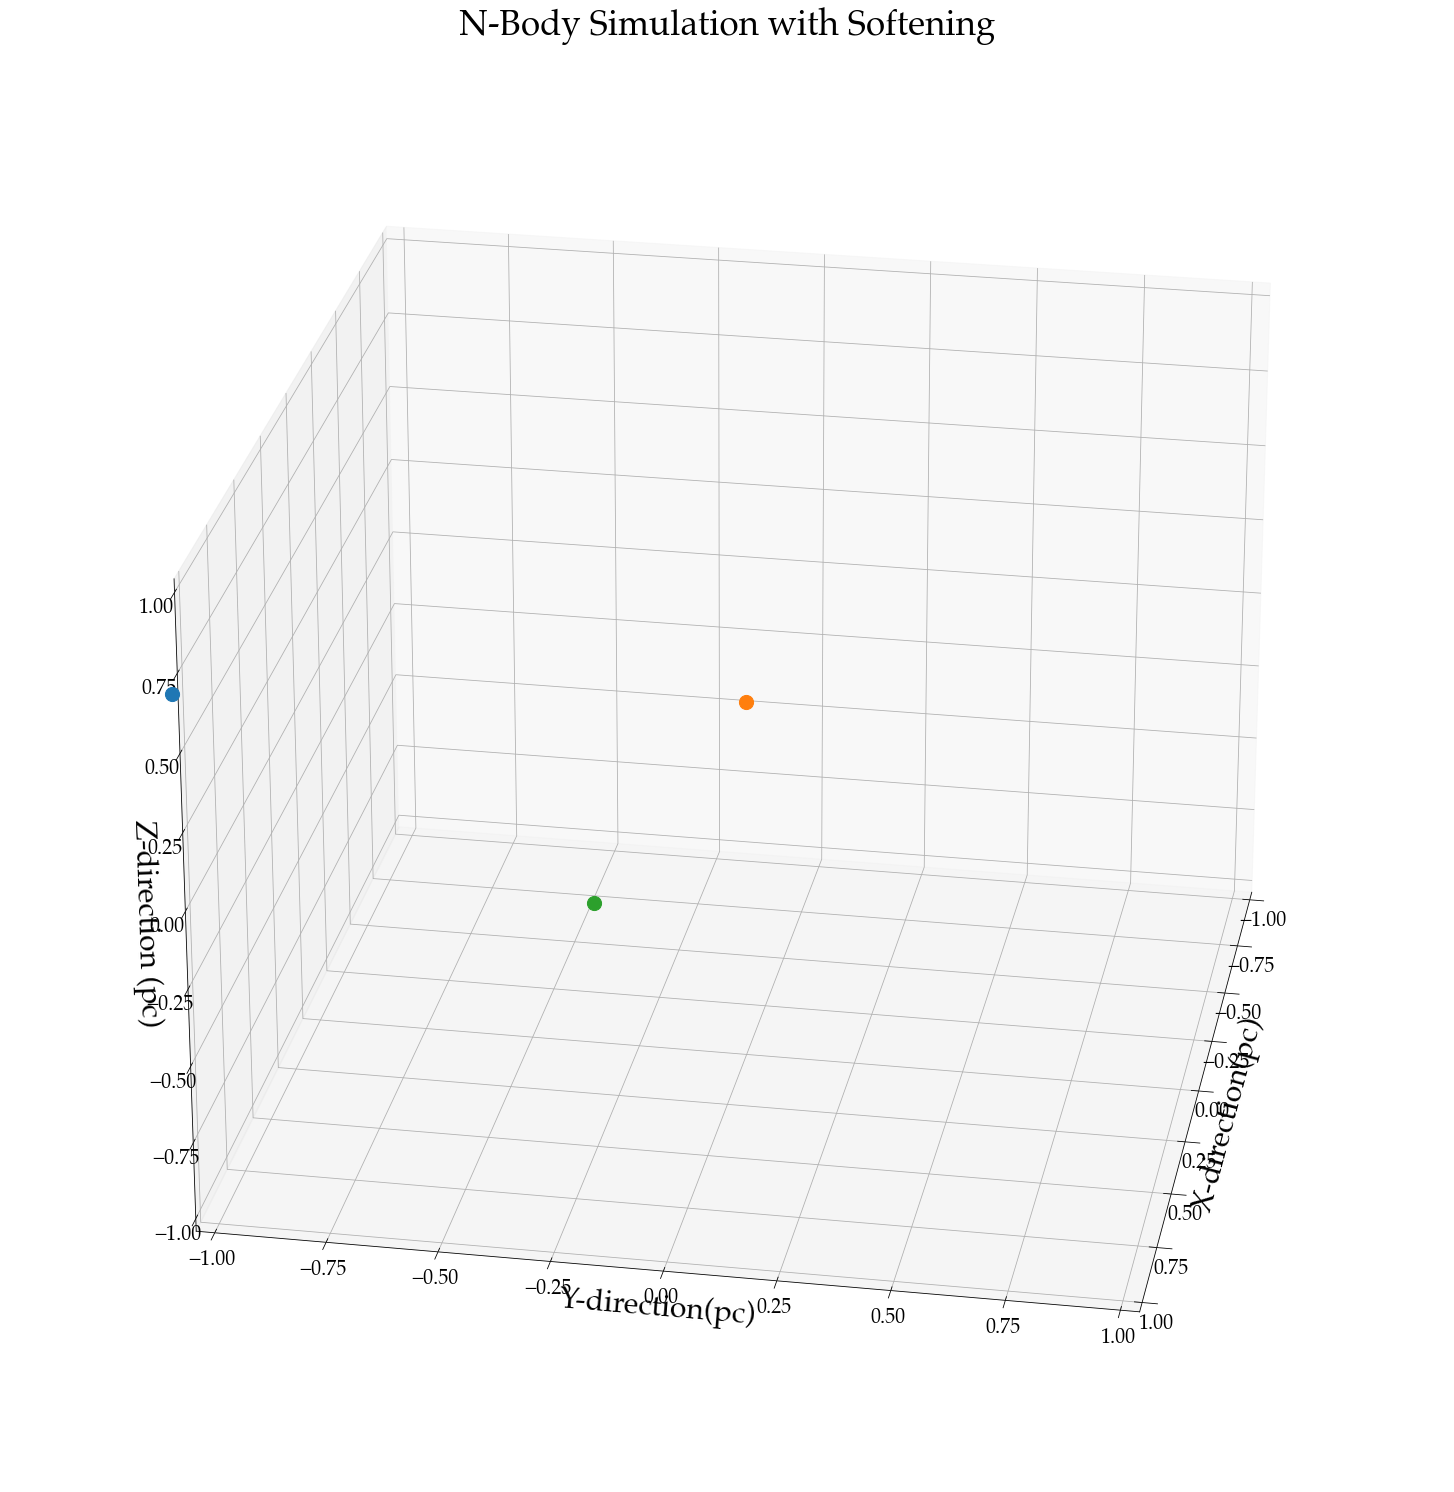

In [75]:
# Author: Pierre Segonne
# Lightly modified from his version: link posted below
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import mpl_toolkits.mplot3d.axes3d as p3
import matplotlib.animation as animation

def generate_data(nbr_iterations, nbr_elements):
    """
    Generates dummy data.
    The elements will be assigned random initial positions and speed.

    Args:
        nbr_iterations (int): Number of iterations data needs to be generated for.
        nbr_elements (int): Number of elements (or points) that will move.

    Returns:
        list: list of positions of elements. (Iterations x (# Elements x Dimensions))
    """
    dims = (3,1)

    # Random initial positions.
    gaussian_mean = np.zeros(dims)
    gaussian_std = np.ones(dims)
    start_positions = np.array(list(map(np.random.normal, gaussian_mean, gaussian_std, [nbr_elements] * dims[0]))).T

    # Random speed
    start_speed = np.array(list(map(np.random.normal, gaussian_mean, gaussian_std, [nbr_elements] * dims[0]))).T

    # Computing trajectory
    data = [start_positions]
    for iteration in range(nbr_iterations):
        previous_positions = data[-1]
        new_positions = previous_positions + start_speed
        data.append(new_positions)

    return data

def animate_scatters(iteration, data, scatters):
    """
    Update the data held by the scatter plot and therefore animates it.

    Args:
        iteration (int): Current iteration of the animation
        data (list): List of the data positions at each iteration.
        scatters (list): List of all the scatters (One per element)

    Returns:
        list: List of scatters (One per element) with new coordinates
    """
    for i in range(data[0].shape[0]):
        scatters[i]._offsets3d = (data[iteration][i,0:1], data[iteration][i,1:2], data[iteration][i,2:])
    return scatters

def main(data, softening, save=False):
    """
    Creates the 3D figure and animates it with the input data.

    Args:
        data (list): List of the data positions at each iteration.
        save (bool): Whether to save the recording of the animation. (Default to False).
    """

    # Attaching 3D axis to the figure
    fig = plt.figure(figsize=(20,20))
    ax = p3.Axes3D(fig)

    # Initialize scatters
    scatters = [ ax.scatter(data[0][i,0:1], data[0][i,1:2], data[0][i,2:],s=200) for i in range(data[0].shape[0]) ]

    # Number of iterations
    iterations = len(data)

    # Setting the axes properties
    ax.set_xlim3d([-1., 1.])
    ax.set_xlabel('X-direction(pc)',fontsize=30)

    ax.set_ylim3d([-1., 1.])
    ax.set_ylabel('Y-direction(pc)',fontsize=30)

    ax.set_zlim3d([-1., 1.])
    ax.set_zlabel('Z-direction (pc)',fontsize=30)
    
    if softening:
        ax.set_title('N-Body Simulation with Softening',fontsize=35)
    else:
        ax.set_title('N-Body Simulation with No Softening',fontsize=35)


    # Provide starting angle for the view.
    ax.view_init(25, 10)

    ani = animation.FuncAnimation(fig, animate_scatters, iterations, fargs=(data, scatters),
                                       interval=50, blit=False, repeat=True)

    if save:
        Writer = animation.writers['ffmpeg']
        writer = Writer(fps=30, metadata=dict(artist='Me'), bitrate=1800, extra_args=['-vcodec', 'libx264'])
        if softening:
            ani.save('N_Body_Simulation_with_Softening.mp4', writer=writer)
        else:
            ani.save('N_Body_Simulation_without_Softening.mp4', writer=writer)

    plt.show()


main(Pos_soft_new, save=True,softening=True)

RuntimeError: Requested MovieWriter (ffmpeg) not available

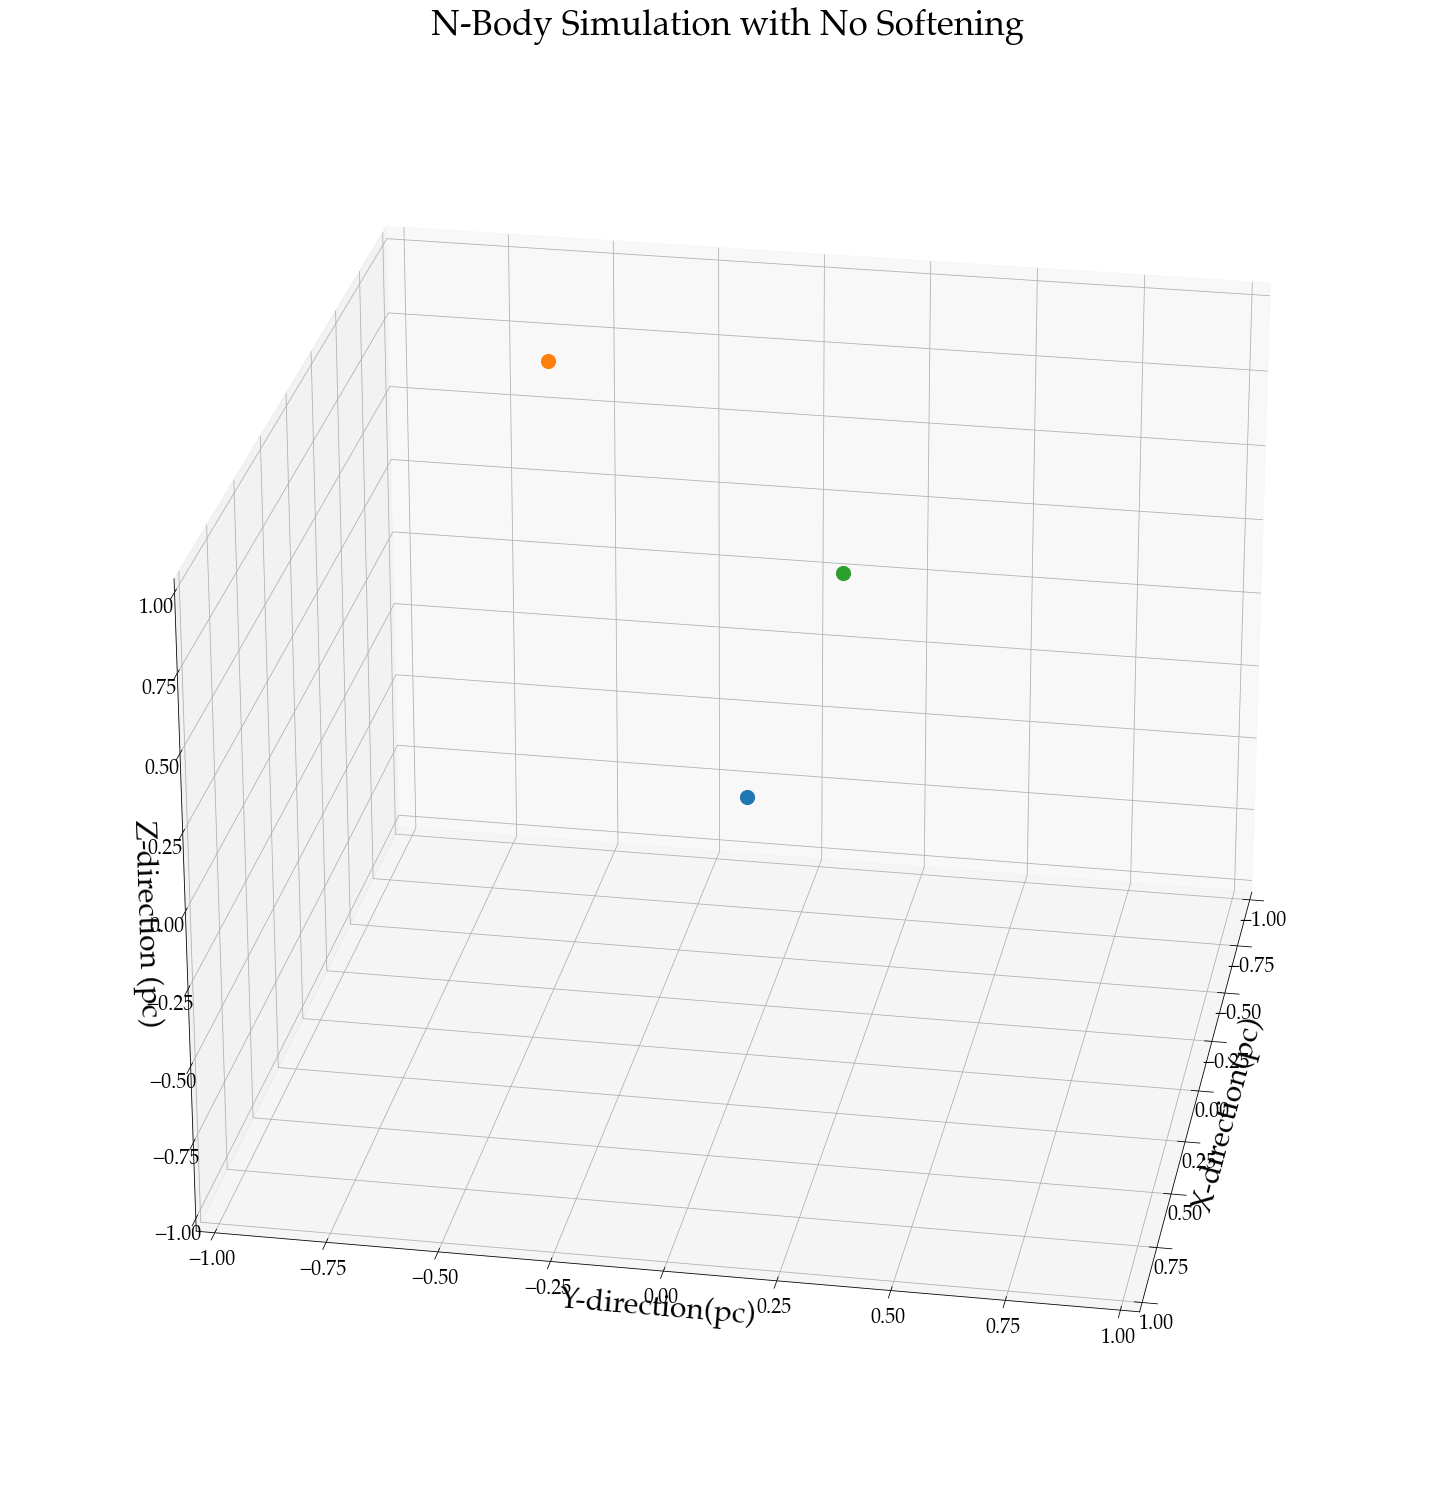

In [76]:
main(Pos_no_soft_new, save=True,softening=False)

Here's the link for the animation code: https://gist.githubusercontent.com/pierresegonne/753575894152687ce01f4ad334e36fd3/raw/099b94d60cd7dbe45d1f43afac7724857f69b57b/full_tuto_3d-scatter-animated.py

Note: timesteps are on the order of 0.01 Myr, and the simulation lasts 10 Myr with 500 timesteps of size $~\sim$ 0.01 Myr